# Clasificación: Detección de Fatiga Muscular en Ciclismo 

In [8]:
from datasets import load_dataset
import numpy as np
import pandas as pd
from scipy.signal import welch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.metrics import Precision, Recall
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.layers import Input
from scipy.stats import uniform
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import (classification_report, confusion_matrix, 
                              ConfusionMatrixDisplay)

## Paso 1: Análisis Preliminar del Problema

In [9]:
ds = load_dataset("YominE/Muscle_Fatigue_Cycling")
df = ds["train"].to_pandas()

fs = 1000
window_size = fs # 1 segundo = 1000 muestras

channels = ['Right Rectus femoris', 'Left Gluteus maximus',
       'Left Gastrocnemius medialis', 'Left Semitendinosus',
       'Left Biceps femoris caput longus', 'Right Vastus medialis',
       'Right Tibialis anterior', 'Left Gastrocnemius lateralis']

# Calcular cuántas ventanas completas caben
n_windows = len(df) // window_size

df = df.replace(2 , 1)

print(df.head())
print(f"Total de muestras: {len(df)}")
print(f"Ventanas de 1 segundo: {n_windows}")

    Time  Right Rectus femoris  Left Gluteus maximus  \
0  0.000             -0.000264             -0.000015   
1  0.001             -0.001002             -0.000045   
2  0.002             -0.002173             -0.000034   
3  0.003             -0.002676              0.000185   
4  0.004             -0.000844              0.000785   

   Left Gastrocnemius medialis  Left Semitendinosus  \
0                     0.000344             0.000108   
1                     0.001342             0.000429   
2                     0.002944             0.001133   
3                     0.003504             0.002319   
4                     0.000426             0.003950   

   Left Biceps femoris caput longus  Right Vastus medialis  \
0                          0.000182               0.000401   
1                          0.000712               0.002234   
2                          0.001692               0.007634   
3                          0.002820               0.017656   
4                     

Observando la cabecera del DataFrame, se puede apreciar que contiene 10 columnas. Ocho de ellas corresponden a las mediciones de las señales EMG provenientes de ocho músculos del pie dominante de la persona que realiza la prueba de ciclismo. Estas ocho columnas son variables numéricas continuas.
Por otro lado, se encuentra la columna de tiempo, la cual también corresponde a una variable numérica continua.
Finalmente, está la columna target, que, según la descripción del dataset, presenta un carácter ordinal, ya que refleja una progresión en el nivel de fatiga: 0 indica ausencia de fatiga, 1 representa una transición hacia la fatiga y 2 corresponde a un estado de fatiga. Pero, después del preprocesamiento se convierte en una variable categórica binaria, donde 0 representa la condición normal y 1 el desgaste muscular.

## Paso 2: Extracción de Características (Feature Engineering)

In [10]:

def extraer_caracteristicas(ventana, fs=1000):
    """Extrae características de tiempo y frecuencia de una ventana 1D."""
    # --- Dominio del tiempo ---
    rms     = np.sqrt(np.mean(ventana**2)) # La energía o fuerza promedio de la señal
    varianza = np.var(ventana) # Qué tan dispersos están los valores
    zcr     = np.sum(np.diff(np.sign(ventana)) != 0) # Cuántas veces la señal cruza el cero
    mav     = np.mean(np.abs(ventana)) # Promedio del valor absoluto

    # --- Dominio de la frecuencia ---
    freqs, psd = welch(ventana, fs=fs) 
    pot_acum   = np.cumsum(psd) 
    idx_median = np.searchsorted(pot_acum, pot_acum[-1] / 2)
    frec_mediana = freqs[idx_median] # La frecuencia que divide la potencia espectral en dos mitades iguales

    pot_total  = np.sum(psd) # Energía total de la señal en frecuencia

    frec_media = np.sum(freqs * psd) / np.sum(psd) # Promedio ponderado de las frecuencias	

    return [rms, varianza, zcr, mav, pot_total, frec_media, frec_mediana]

# Construir el nuevo dataset
filas = []

for i in range(n_windows):
    inicio = i * window_size
    fin = inicio + window_size

    ventana_df = df.iloc[inicio:fin] # Todas las filas que estan entre el inicio y el final

    fila = {}

    for canal in channels:
        ventana = ventana_df[canal].values
        feats   = extraer_caracteristicas(ventana, fs=fs)

        nombres = ['rms', 'var', 'zcr', 'mav', 'pot', 'f_media', 'f_mediana']
        for nombre, valor in zip(nombres, feats):
            fila[f'{canal}_{nombre}'] = valor

    # El target de la ventana es el más frecuente en esas 1000 muestras
    fila['target'] = ventana_df['Target'].mode()[0]

    filas.append(fila)

nuevo_df = pd.DataFrame(filas)


### Características seleccionadas

Se seleccionaron las 7 características propuestas en el documento-tutorial del profesor Yomin para cada músculo del dataset.

Esta decisión fue tomada considerando que, al aplicar una agregación por ventanas de un segundo en lugar de trabajar con las mediciones por milisegundo, el dataset pasó de aproximadamente 500.000 filas a 500. Ante esta reducción tan significativa en el número de observaciones, se consideró fundamental extraer la mayor cantidad de información representativa posible por músculo y por ventana.

Cada característica fue seleccionada porque captura un aspecto distinto de la señal: la potencia promedio (RMS, MAV), la dispersión de los valores (varianza), el comportamiento oscilatorio (Zero Crossing Rate) y la distribución de energía en el dominio de la frecuencia (frecuencia media, frecuencia mediana y potencia espectral total).

Contar con estas métricas complementarias garantiza que, aunque el número de filas se haya reducido drásticamente, la esencia de la señal muscular quede preservada a través de sus características más relevantes — asegurando que los modelos dispongan de información suficiente y representativa para entrenarse de manera adecuada.

## Paso 3: EDA

In [11]:
lista_de_features = nuevo_df.columns.to_list()

todos_los_musculos = lista_de_features[0:56]
# Obetener cada musculo con sus 8 caracteristicas
primer_musculo = lista_de_features[0:7]
segundo_musculo = lista_de_features[7:14]
tercer_musculo = lista_de_features[14:21]
cuarto_musculo = lista_de_features[21:28]
quinto_musculo = lista_de_features[28:35]
sexto_musculo = lista_de_features[35:42]
septimo_musculo = lista_de_features[42:49]
octavo_musculo = lista_de_features[49:56]


### Distribuciones de variables y estadísticos descriptivos

In [12]:
def interpretar_estadisticas(serie, nombre):
    desc = serie.describe()
    media = desc['mean']
    mediana = serie.median()
    std = desc['std']
    minimo = desc['min']
    maximo = desc['max']
    nulos = serie.isnull().sum()
    pct_nulos = (nulos / len(serie)) * 100
    skewness = serie.skew()
    kurtosis = serie.kurtosis()
    cv = (std / media * 100) if media != 0 else float('inf')  # Coeficiente de variación

    print(f"\n{'='*60}")
    print(f"  ESTADÍSTICA DESCRIPTIVA: {nombre}")
    print(f"{'='*60}")
    display(desc)

    print(f"\n📋 CONSIDERACIONES:")

    # Nulos
    if pct_nulos == 0:
        print(f"  ✅ Sin valores nulos.")
    elif pct_nulos <= 5:
        print(f"  ⚠️  Nulos leves: {nulos} ({pct_nulos:.1f}%) — considera imputar con media/mediana.")
    elif pct_nulos <= 30:
        print(f"  🔶 Nulos moderados: {nulos} ({pct_nulos:.1f}%) — evalúa imputación avanzada (KNN, MICE).")
    else:
        print(f"  🔴 Nulos críticos: {nulos} ({pct_nulos:.1f}%) — considera eliminar la feature.")

    # Sesgo (Skewness)
    if abs(skewness) < 0.5:
        print(f"  ✅ Distribución simétrica (skewness={skewness:.2f}) — sin transformación necesaria.")
    elif abs(skewness) < 1:
        print(f"  ⚠️  Sesgo moderado (skewness={skewness:.2f}) — puede funcionar bien, monitorea el modelo.")
    else:
        direccion = "positivo (cola derecha)" if skewness > 0 else "negativo (cola izquierda)"
        print(f"  🔶 Sesgo fuerte {direccion} (skewness={skewness:.2f}) — considera transformación log/sqrt/Box-Cox.")

    # Curtosis
    if abs(kurtosis) < 1:
        print(f"  ✅ Curtosis normal (kurtosis={kurtosis:.2f}) — colas ligeras, pocos outliers extremos.")
    elif kurtosis >= 1:
        print(f"  ⚠️  Curtosis alta (kurtosis={kurtosis:.2f}) — colas pesadas, probables outliers significativos.")
    else:
        print(f"  ℹ️  Curtosis negativa (kurtosis={kurtosis:.2f}) — distribución aplanada, datos muy dispersos.")

    # Media vs Mediana
    if media != 0:
        diff_pct = abs((media - mediana) / media) * 100
        if diff_pct < 5:
            print(f"  ✅ Media ({media:.2f}) ≈ Mediana ({mediana:.2f}) — distribución balanceada.")
        elif diff_pct < 20:
            print(f"  ⚠️  Media ({media:.2f}) y Mediana ({mediana:.2f}) difieren ({diff_pct:.1f}%) — sesgo o outliers presentes.")
        else:
            print(f"  🔶 Gran diferencia Media ({media:.2f}) vs Mediana ({mediana:.2f}) ({diff_pct:.1f}%) — outliers distorsionan la media.")

    # Variabilidad (Coeficiente de variación)
    if cv < 15:
        print(f"  ⚠️  Baja variabilidad (CV={cv:.1f}%) — la feature puede aportar poca información al modelo.")
    elif cv <= 100:
        print(f"  ✅ Variabilidad adecuada (CV={cv:.1f}%) — la feature tiene dispersión útil.")
    else:
        print(f"  🔶 Variabilidad muy alta (CV={cv:.1f}%) — revisa outliers o considera normalización.")

    # Rango
    rango = maximo - minimo
    print(f"  ℹ️  Rango: [{minimo:.2f} — {maximo:.2f}] (amplitud={rango:.2f})")
    if rango == 0:
        print(f"  🔴 Rango = 0: feature constante, no aporta nada — elimínala.")

La estadistica descriptiva de la caracteristica Right Rectus femoris_rms

  ESTADÍSTICA DESCRIPTIVA: Right Rectus femoris_rms


count    3002.000000
mean        0.035700
std         0.024379
min         0.002970
25%         0.021569
50%         0.029745
75%         0.042171
max         0.190683
Name: Right Rectus femoris_rms, dtype: float64


📋 CONSIDERACIONES:
  ✅ Sin valores nulos.
  🔶 Sesgo fuerte positivo (cola derecha) (skewness=2.78) — considera transformación log/sqrt/Box-Cox.
  ⚠️  Curtosis alta (kurtosis=10.15) — colas pesadas, probables outliers significativos.
  ⚠️  Media (0.04) y Mediana (0.03) difieren (16.7%) — sesgo o outliers presentes.
  ✅ Variabilidad adecuada (CV=68.3%) — la feature tiene dispersión útil.
  ℹ️  Rango: [0.00 — 0.19] (amplitud=0.19)


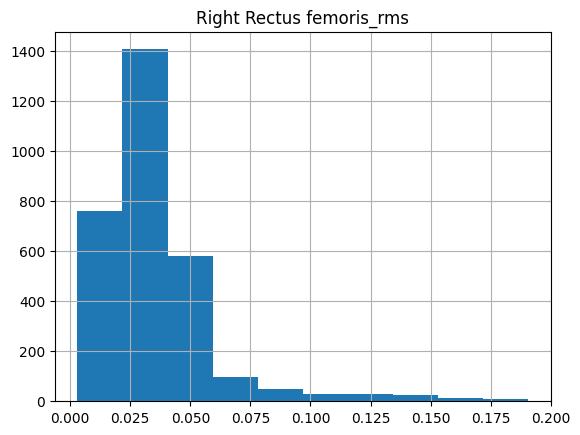

La estadistica descriptiva de la caracteristica Right Rectus femoris_var

  ESTADÍSTICA DESCRIPTIVA: Right Rectus femoris_var


count    3002.000000
mean        0.001869
std         0.003613
min         0.000009
25%         0.000465
50%         0.000885
75%         0.001778
max         0.036360
Name: Right Rectus femoris_var, dtype: float64


📋 CONSIDERACIONES:
  ✅ Sin valores nulos.
  🔶 Sesgo fuerte positivo (cola derecha) (skewness=5.12) — considera transformación log/sqrt/Box-Cox.
  ⚠️  Curtosis alta (kurtosis=30.59) — colas pesadas, probables outliers significativos.
  🔶 Gran diferencia Media (0.00) vs Mediana (0.00) (52.7%) — outliers distorsionan la media.
  🔶 Variabilidad muy alta (CV=193.4%) — revisa outliers o considera normalización.
  ℹ️  Rango: [0.00 — 0.04] (amplitud=0.04)


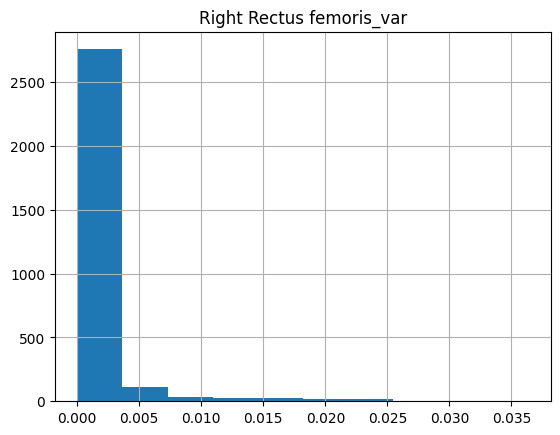

La estadistica descriptiva de la caracteristica Right Rectus femoris_zcr

  ESTADÍSTICA DESCRIPTIVA: Right Rectus femoris_zcr


count    3002.000000
mean      108.874084
std        13.094489
min        63.000000
25%       100.000000
50%       109.000000
75%       118.000000
max       155.000000
Name: Right Rectus femoris_zcr, dtype: float64


📋 CONSIDERACIONES:
  ✅ Sin valores nulos.
  ✅ Distribución simétrica (skewness=0.13) — sin transformación necesaria.
  ✅ Curtosis normal (kurtosis=-0.01) — colas ligeras, pocos outliers extremos.
  ✅ Media (108.87) ≈ Mediana (109.00) — distribución balanceada.
  ⚠️  Baja variabilidad (CV=12.0%) — la feature puede aportar poca información al modelo.
  ℹ️  Rango: [63.00 — 155.00] (amplitud=92.00)


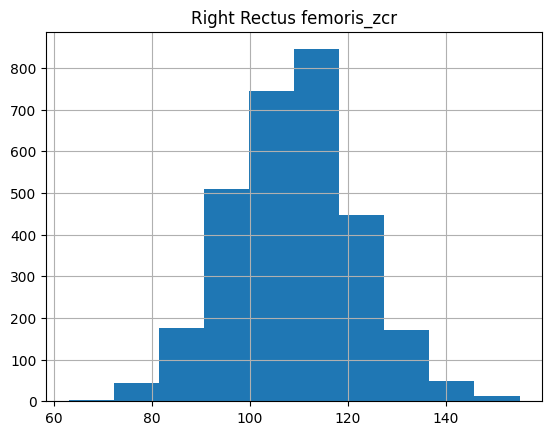

La estadistica descriptiva de la caracteristica Right Rectus femoris_mav

  ESTADÍSTICA DESCRIPTIVA: Right Rectus femoris_mav


count    3002.000000
mean        0.022596
std         0.015262
min         0.002243
25%         0.013461
50%         0.018516
75%         0.026945
max         0.128436
Name: Right Rectus femoris_mav, dtype: float64


📋 CONSIDERACIONES:
  ✅ Sin valores nulos.
  🔶 Sesgo fuerte positivo (cola derecha) (skewness=2.84) — considera transformación log/sqrt/Box-Cox.
  ⚠️  Curtosis alta (kurtosis=10.83) — colas pesadas, probables outliers significativos.
  ⚠️  Media (0.02) y Mediana (0.02) difieren (18.1%) — sesgo o outliers presentes.
  ✅ Variabilidad adecuada (CV=67.5%) — la feature tiene dispersión útil.
  ℹ️  Rango: [0.00 — 0.13] (amplitud=0.13)


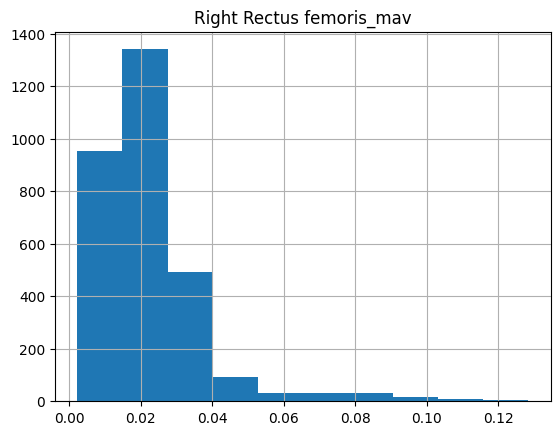

La estadistica descriptiva de la caracteristica Right Rectus femoris_pot

  ESTADÍSTICA DESCRIPTIVA: Right Rectus femoris_pot


count    3002.000000
mean        0.000483
std         0.000982
min         0.000002
25%         0.000099
50%         0.000223
75%         0.000444
max         0.011503
Name: Right Rectus femoris_pot, dtype: float64


📋 CONSIDERACIONES:
  ✅ Sin valores nulos.
  🔶 Sesgo fuerte positivo (cola derecha) (skewness=5.60) — considera transformación log/sqrt/Box-Cox.
  ⚠️  Curtosis alta (kurtosis=39.26) — colas pesadas, probables outliers significativos.
  🔶 Gran diferencia Media (0.00) vs Mediana (0.00) (53.8%) — outliers distorsionan la media.
  🔶 Variabilidad muy alta (CV=203.5%) — revisa outliers o considera normalización.
  ℹ️  Rango: [0.00 — 0.01] (amplitud=0.01)


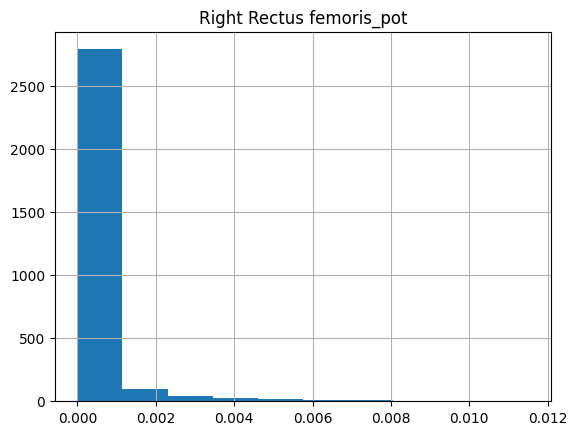

La estadistica descriptiva de la caracteristica Right Rectus femoris_f_media

  ESTADÍSTICA DESCRIPTIVA: Right Rectus femoris_f_media


count    3002.000000
mean       54.015741
std         6.264138
min        20.487091
25%        50.660326
50%        54.555808
75%        58.067109
max        71.694239
Name: Right Rectus femoris_f_media, dtype: float64


📋 CONSIDERACIONES:
  ✅ Sin valores nulos.
  ⚠️  Sesgo moderado (skewness=-0.92) — puede funcionar bien, monitorea el modelo.
  ⚠️  Curtosis alta (kurtosis=2.59) — colas pesadas, probables outliers significativos.
  ✅ Media (54.02) ≈ Mediana (54.56) — distribución balanceada.
  ⚠️  Baja variabilidad (CV=11.6%) — la feature puede aportar poca información al modelo.
  ℹ️  Rango: [20.49 — 71.69] (amplitud=51.21)


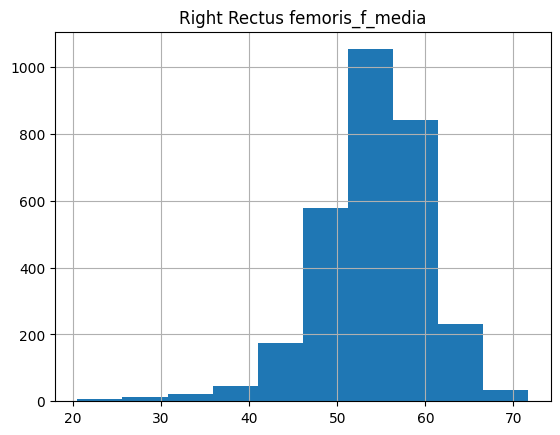

La estadistica descriptiva de la caracteristica Right Rectus femoris_f_mediana

  ESTADÍSTICA DESCRIPTIVA: Right Rectus femoris_f_mediana


count    3002.000000
mean       47.493078
std         8.368634
min        15.625000
25%        42.968750
50%        46.875000
75%        50.781250
max        74.218750
Name: Right Rectus femoris_f_mediana, dtype: float64


📋 CONSIDERACIONES:
  ✅ Sin valores nulos.
  ✅ Distribución simétrica (skewness=-0.42) — sin transformación necesaria.
  ⚠️  Curtosis alta (kurtosis=1.02) — colas pesadas, probables outliers significativos.
  ✅ Media (47.49) ≈ Mediana (46.88) — distribución balanceada.
  ✅ Variabilidad adecuada (CV=17.6%) — la feature tiene dispersión útil.
  ℹ️  Rango: [15.62 — 74.22] (amplitud=58.59)


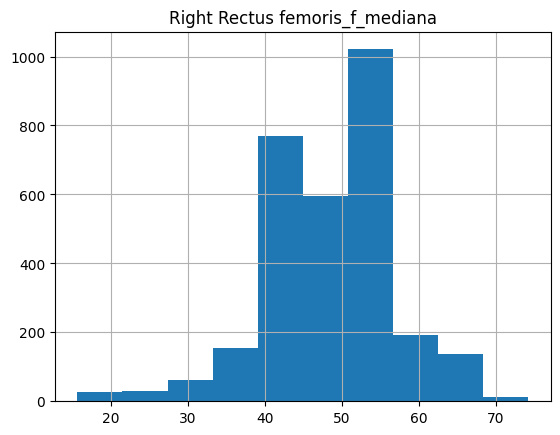

In [13]:
# Descomentar si se quieren graficar todas las features

# for caracteristica in todos_los_musculos
for caracteristica in primer_musculo:
    print(f"La estadistica descriptiva de la caracteristica {caracteristica}")
    interpretar_estadisticas(nuevo_df[caracteristica], caracteristica)

    nuevo_df.hist(column=caracteristica)
    plt.show()


### Matriz de correlaciones

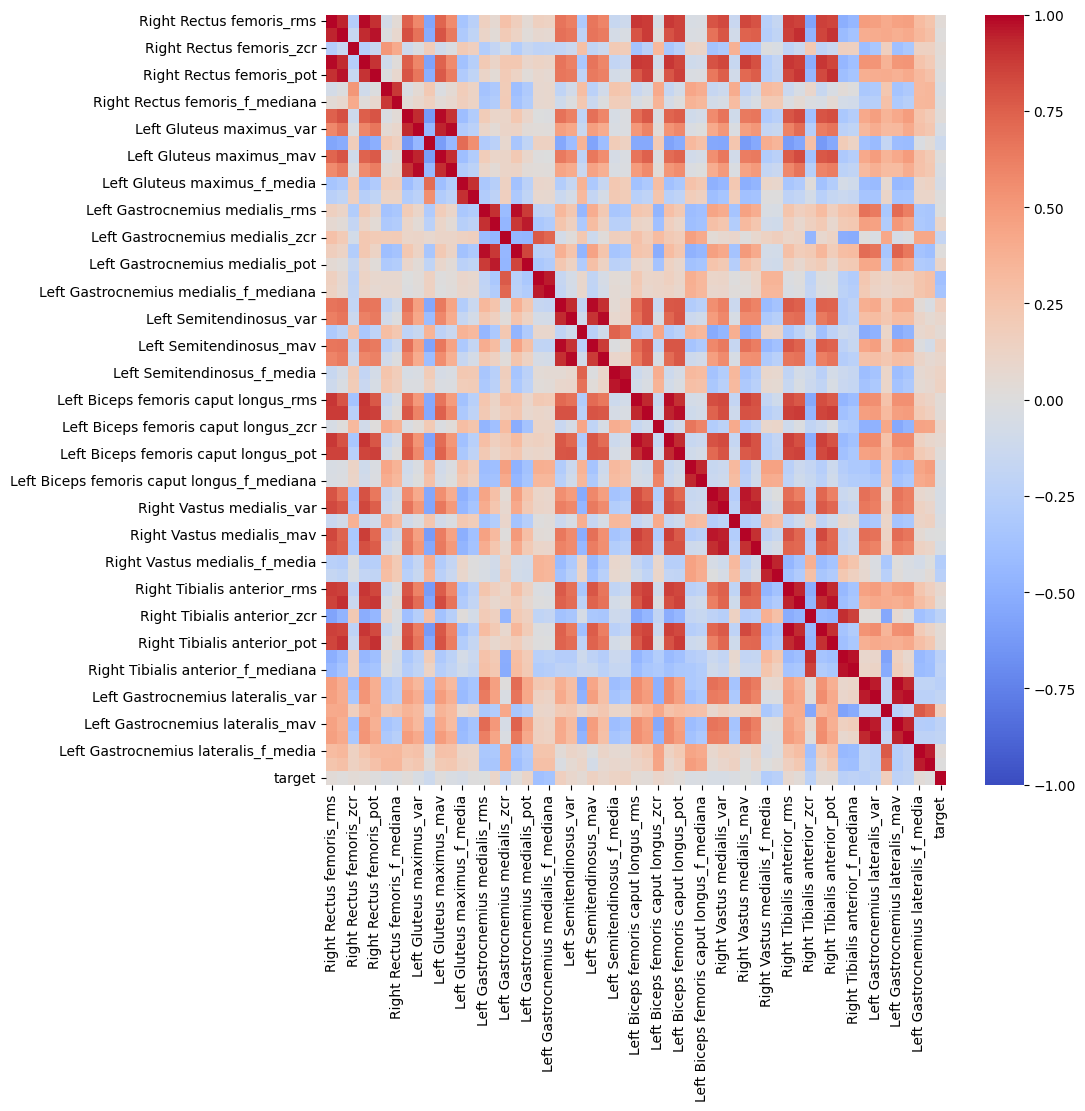

In [14]:
corr = nuevo_df.corr(method='pearson')
plt.figure(figsize=(10 , 10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
)
plt.show()

Ya que, como la matriz de correlaciones es simetrica, podemos observarla con unicamente ver la parte triangular superior o inferior sin la diagonal. En este caso vamos a ver la parte triangular superior

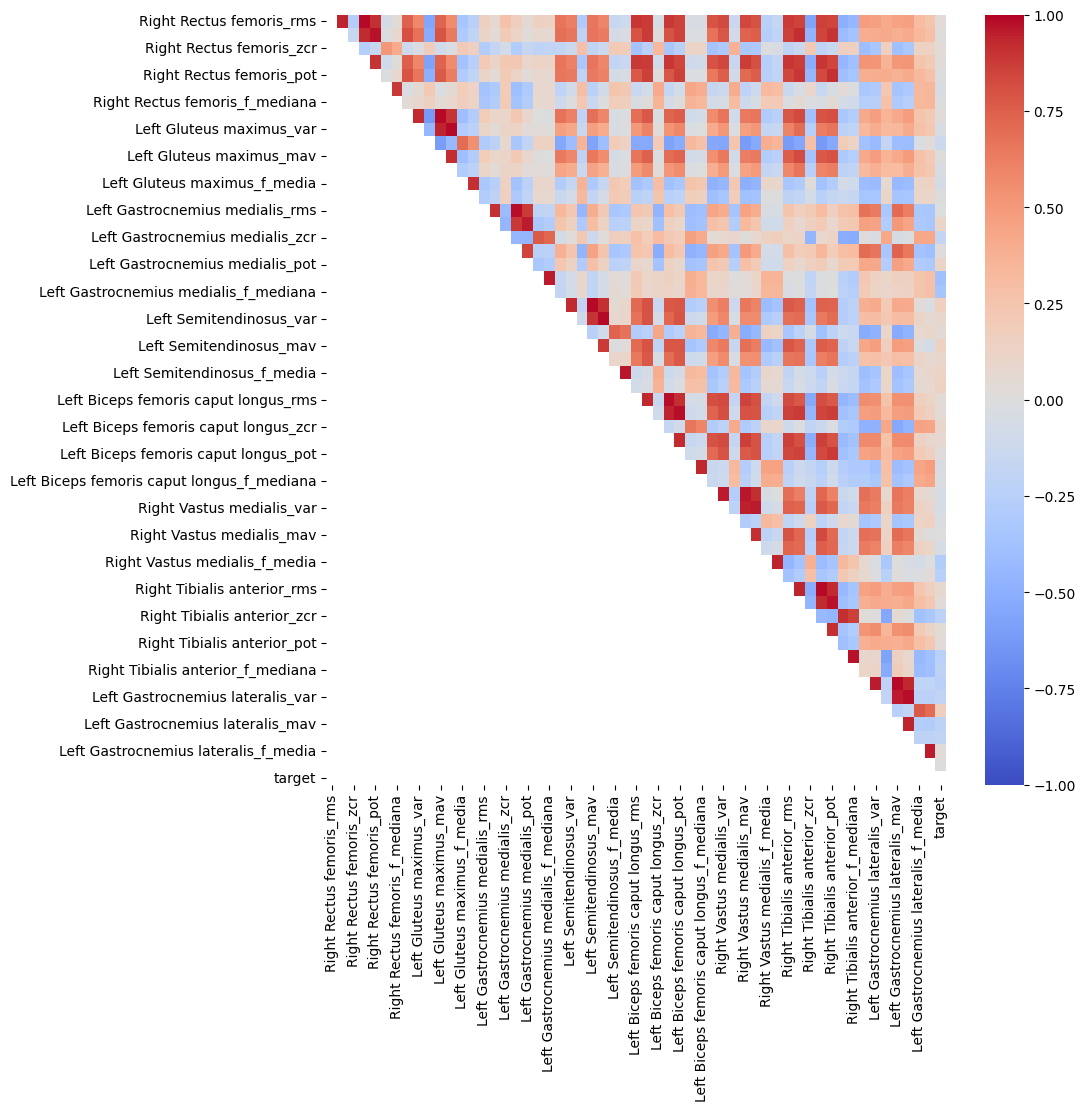

In [15]:
tri_superior = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)) # Triangular superior sin diagonal
plt.figure(figsize=(10 , 10))
sns.heatmap(
    tri_superior,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
)
plt.show()

In [16]:
top_20 = (
    tri_superior
    .stack()
    .reset_index()
)

top_20.columns = ['variable_1', 'variable_2', 'correlacion']
top_20['abs_corr'] = top_20['correlacion'].abs() # Util para ordenar. Una correlacion negativa tambien puede ser muy fuerte

top_20 = top_20.sort_values('abs_corr', ascending=False).head(20)

print(top_20)

                                variable_1  \
409               Left Gluteus maximus_rms   
1221               Left Semitendinosus_rms   
467               Left Gluteus maximus_var   
3                 Right Rectus femoris_rms   
2845      Left Gastrocnemius lateralis_rms   
2439           Right Tibialis anterior_rms   
1279               Left Semitendinosus_var   
1627  Left Biceps femoris caput longus_rms   
815        Left Gastrocnemius medialis_rms   
2903      Left Gastrocnemius lateralis_var   
1685  Left Biceps femoris caput longus_var   
61                Right Rectus femoris_var   
2727       Right Tibialis anterior_f_media   
2497           Right Tibialis anterior_var   
2033             Right Vastus medialis_rms   
1509           Left Semitendinosus_f_media   
1103   Left Gastrocnemius medialis_f_media   
2031             Right Vastus medialis_rms   
2902      Left Gastrocnemius lateralis_var   
873        Left Gastrocnemius medialis_var   

                                 

### Correlaciones

Se puede observar que hay una gran cantidad de features altamente correlacionadas entre sí (con coeficientes cercanos a 1). Esto introduce redundancia en los datos, lo que equivale a pasarle la misma información al modelo dos veces. Como consecuencia, ciertos modelos pueden tener dificultades asignando pesos a estas features, ya que no existe una distinción clara entre su contribución individual al aprendizaje.

Frente a esto, existen dos enfoques principales. El primero es eliminar directamente una de las features correlacionadas, conservando aquella que tenga mayor correlación con el target — es la opción más simple e interpretable. El segundo es aplicar PCA, que en lugar de descartar información, la combina en componentes que capturan la varianza útil de ambas features simultáneamente — es más adecuado cuando la redundancia es generalizada en el dataset. La elección entre uno u otro dependerá del modelo que se utilice y de qué tan importante sea mantener la interpretabilidad de las features.

### Relación entre características-target y análisis de balance de clases

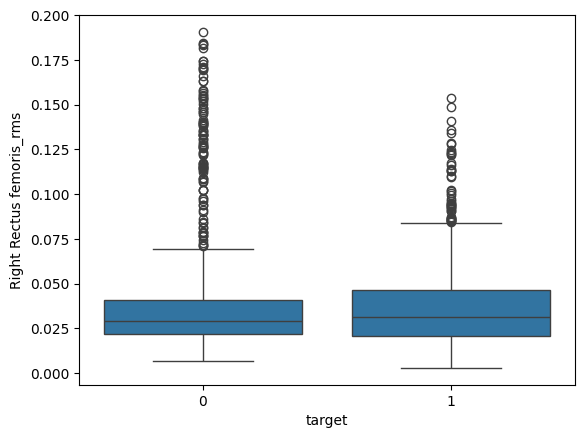

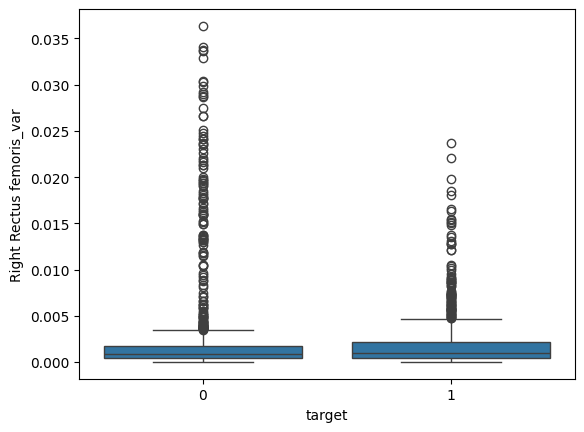

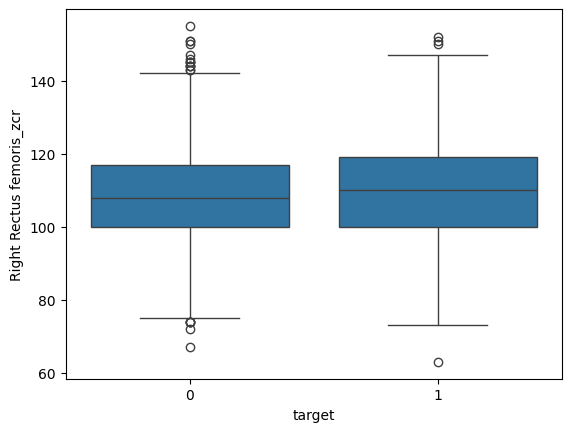

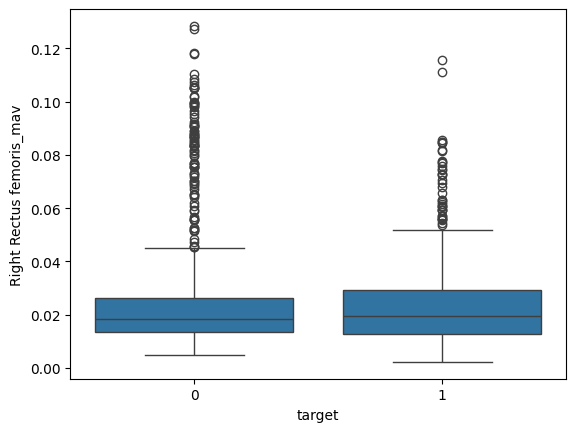

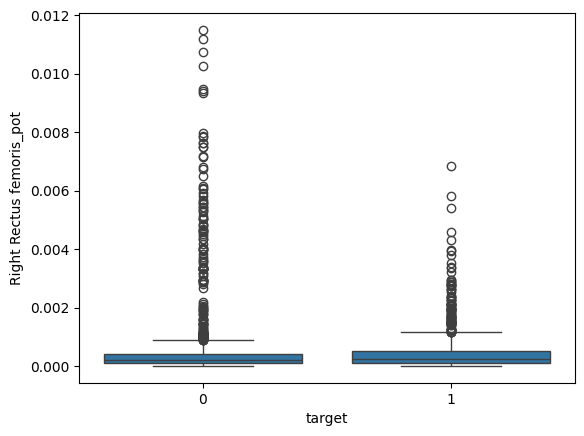

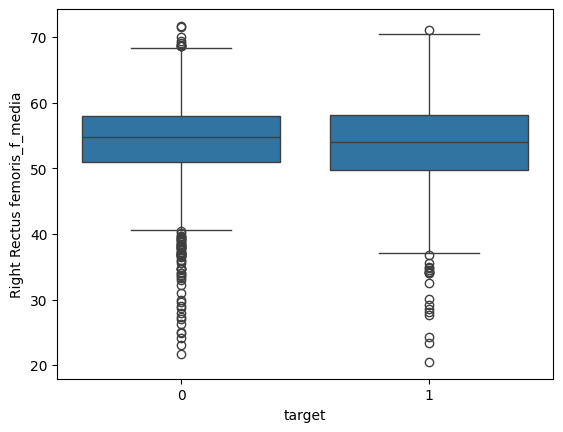

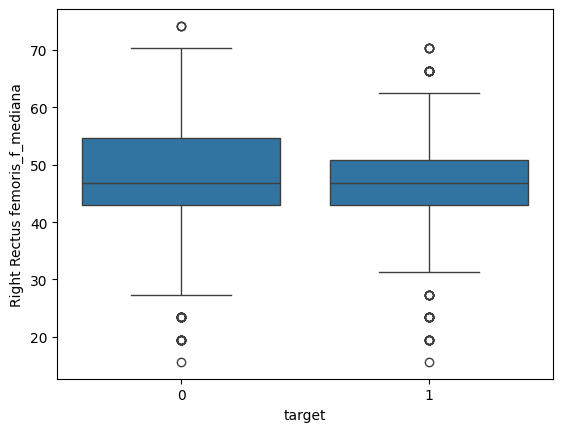

Proporciones de las clases


target
0    2128
1     874
Name: count, dtype: int64

target
0    70.886076
1    29.113924
Name: proportion, dtype: float64

In [17]:
for caracteristica in primer_musculo:
    sns.boxplot(x=nuevo_df['target'], y=nuevo_df[caracteristica])
    plt.show()

print("Proporciones de las clases")
display(nuevo_df['target'].value_counts())
display(nuevo_df['target'].value_counts(normalize=True) * 100)

### Balance de clases

Se observa un desbalance moderado entre las clases del target, con un 70.9% correspondiente a la clase 0 (No fatigado) y un 29.1% a la clase 1 (Fatigado). 

Esto es importante tenerlo en cuenta durante el modelado, ya que un modelo que predijera siempre la clase mayoritaria obtendría un accuracy del ~71% sin haber aprendido ningún patrón real. Por esta razón, el accuracy no será una métrica confiable para evaluar el desempeño — se priorizarán métricas como F1-Score y se considerará el uso de class_weight='balanced' para que el modelo penalice proporcionalmente los errores en la clase minoritaria.

In [18]:
PESOS = {
    'nulos':        0.30,
    'variabilidad': 0.25,
    'correlacion':  0.30,
    'sesgo':        0.15,
}

def normalizar(score, target):
    _, conteos = np.unique(target, return_counts=True)
    probs = conteos / conteos.sum()
    entropia_target = entropy(probs, base=2)
    if entropia_target == 0:
        return 0.0
    return min(score / entropia_target, 1.0)

def score_feature(serie, _, target):
    pct_nulos = serie.isnull().mean()
    skewness  = abs(serie.skew())
    media     = serie.mean()
    cv        = serie.std() / media if media != 0 else 0

    # --- Nulos ---
    if pct_nulos == 0:           s_nulos = 1.0
    elif pct_nulos <= 0.05:      s_nulos = 0.7
    elif pct_nulos <= 0.30:      s_nulos = 0.3
    else:                        s_nulos = 0.0

    # --- Variabilidad ---
    if cv == 0:                  s_var = 0.0
    elif cv < 0.15:              s_var = 0.3
    elif cv <= 1.0:              s_var = 1.0
    else:                        s_var = 0.6

    # --- Sesgo ---
    if skewness < 0.5:           s_sesgo = 1.0
    elif skewness < 1.0:         s_sesgo = 0.6
    else:                        s_sesgo = 0.3

    # --- Correlación con target (Mutual Information) ---
    serie_limpia     = serie.dropna()
    target_alineado  = target[serie_limpia.index]

    raw  = mutual_info_classif(
        serie_limpia.values.reshape(-1, 1),
        target_alineado,
        random_state=42
    )[0]

    s_corr = normalizar(raw, target_alineado)

    # --- Score final ponderado ---
    score = (
        s_nulos  * PESOS['nulos']       +
        s_var    * PESOS['variabilidad'] +
        s_sesgo  * PESOS['sesgo']       +
        s_corr   * PESOS['correlacion']
    )

    return round(score, 3)


features_malas    = []
features_decentes = []
features_buenas   = []

for caracteristica in todos_los_musculos:
    score = score_feature(nuevo_df[caracteristica], caracteristica, nuevo_df['target'])  # Cambia 'target' por tu columna
    
    print(f"Feature: {caracteristica:<30} Score: {score:.3f}", end="  →  ")
    
    if score < 0.50:
        print("🔴 Mala")
        features_malas.append(caracteristica)
    elif score < 0.70:
        print("🟡 Decente")
        features_decentes.append(caracteristica)
    else:
        print("🟢 Buena")
        features_buenas.append(caracteristica)

# --- Resumen final ---
print(f"\n{'='*50}")
print(f"🟢 Features buenas   ({len(features_buenas)}):   {features_buenas}")
print(f"🟡 Features decentes ({len(features_decentes)}): {features_decentes}")
print(f"🔴 Features malas    ({len(features_malas)}):    {features_malas}")

Feature: Right Rectus femoris_rms       Score: 0.602  →  🟡 Decente
Feature: Right Rectus femoris_var       Score: 0.502  →  🟡 Decente
Feature: Right Rectus femoris_zcr       Score: 0.525  →  🟡 Decente
Feature: Right Rectus femoris_mav       Score: 0.601  →  🟡 Decente
Feature: Right Rectus femoris_pot       Score: 0.508  →  🟡 Decente
Feature: Right Rectus femoris_f_media   Score: 0.465  →  🔴 Mala
Feature: Right Rectus femoris_f_mediana Score: 0.700  →  🟢 Buena
Feature: Left Gluteus maximus_rms       Score: 0.509  →  🟡 Decente
Feature: Left Gluteus maximus_var       Score: 0.509  →  🟡 Decente
Feature: Left Gluteus maximus_zcr       Score: 0.470  →  🔴 Mala
Feature: Left Gluteus maximus_mav       Score: 0.509  →  🟡 Decente
Feature: Left Gluteus maximus_pot       Score: 0.502  →  🟡 Decente
Feature: Left Gluteus maximus_f_media   Score: 0.706  →  🟢 Buena
Feature: Left Gluteus maximus_f_mediana Score: 0.645  →  🟡 Decente
Feature: Left Gastrocnemius medialis_rms Score: 0.616  →  🟡 Decente
Feat

### Conclusiones del EDA

Las únicas features que superaron un umbral del 70% en la suma ponderada de calidad de datos valores nulos, variabilidad, sesgo y correlación con el target fueron las siguientes 7:

- Right Rectus femoris_f_mediana
- Left Gluteus maximus_f_media
- Left Semitendinosus_zcr
- Right Vastus medialis_f_mediana
- Right Tibialis anterior_f_media
- Right Tibialis anterior_f_mediana
- Left Gastrocnemius lateralis_zcr

Analizar estas métricas de forma conjunta fue fundamental, ya que cada una por separado puede llevar a conclusiones incorrectas.

Si solo hubiéramos observado los histogramas y estadísticos descriptivos, podríamos haber descartado features con alta asimetría asumiendo que no aportarían información útil al modelo. Sin embargo, la asimetría afecta principalmente a modelos paramétricos y no determina por sí sola si una feature es informativa.

Si solo hubiéramos analizado los boxplots, podríamos haber eliminado features con muchos outliers bajo el supuesto de que representaban ruido. No obstante, en señales fisiológicas como las de este dataset, los valores extremos pueden corresponder a eventos musculares relevantes y no necesariamente a errores de medición.

Esta información se complementa de gran manera al incorporar la correlación entre cada feature y el target. La presencia de una correlación significativa entre una característica y la variable objetivo (en este caso una clasificación 0 o 1) indica que dicha feature contiene información valiosa que el modelo puede aprovechar para realizar predicciones más acertadas.

En conclusión, ninguna métrica aislada es suficiente para determinar si una feature es útil. Una distribución perfectamente normal no garantiza poder predictivo. Una variabilidad adecuada no sirve si hay un porcentaje crítico de valores nulos. Y una alta correlación con el target pierde valor si la feature carece de variabilidad real o está plagada de datos faltantes.

La decisión más robusta se obtiene evaluando todas estas dimensiones de forma simultánea, ponderando cada una según su impacto real en el aprendizaje del modelo, obteniendo así las features más robustas que, estadísticamente, aportan mayor valor predictivo.

### Señales en el tiempo

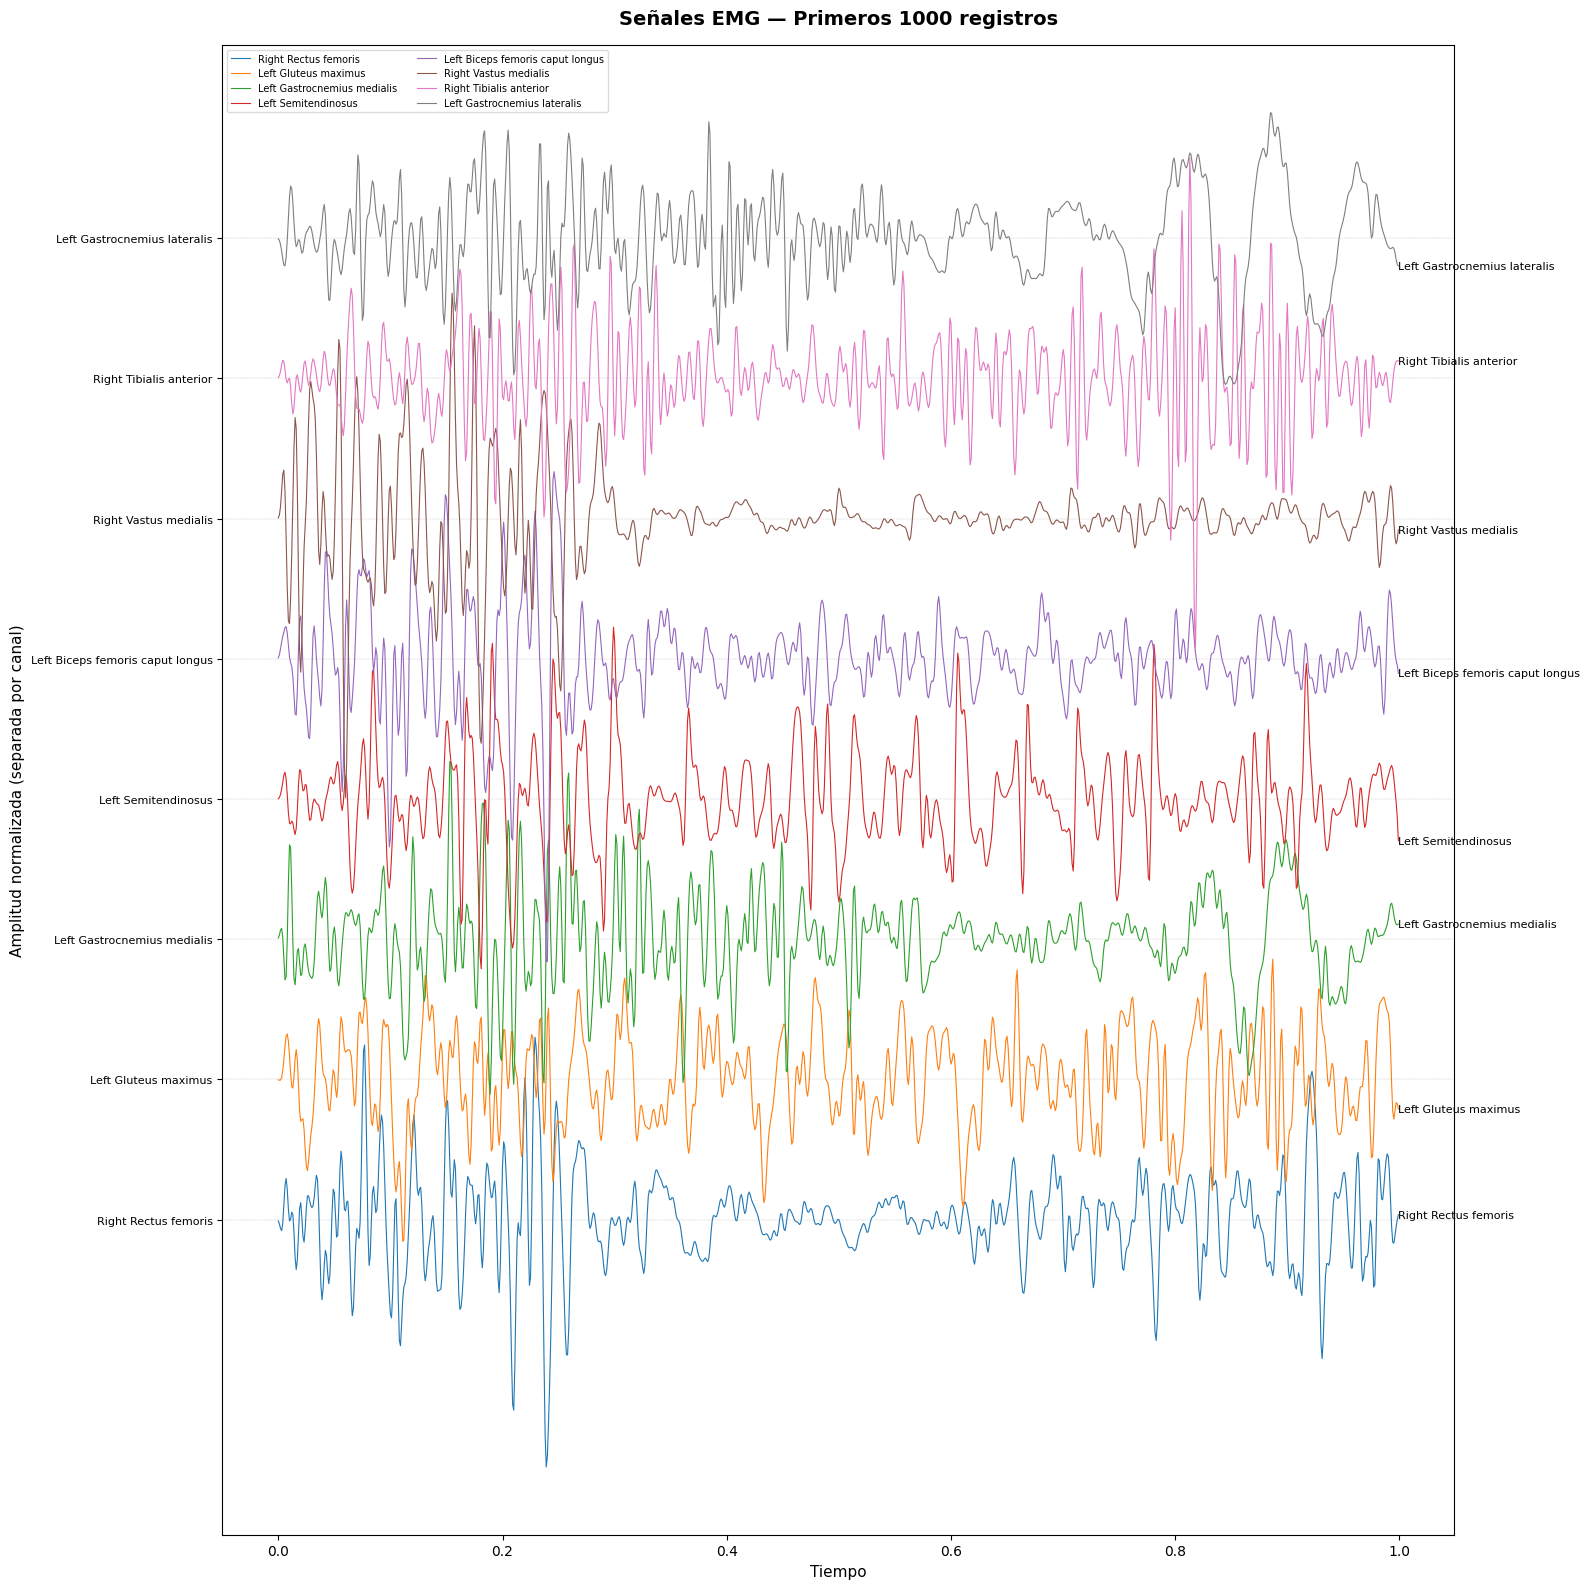

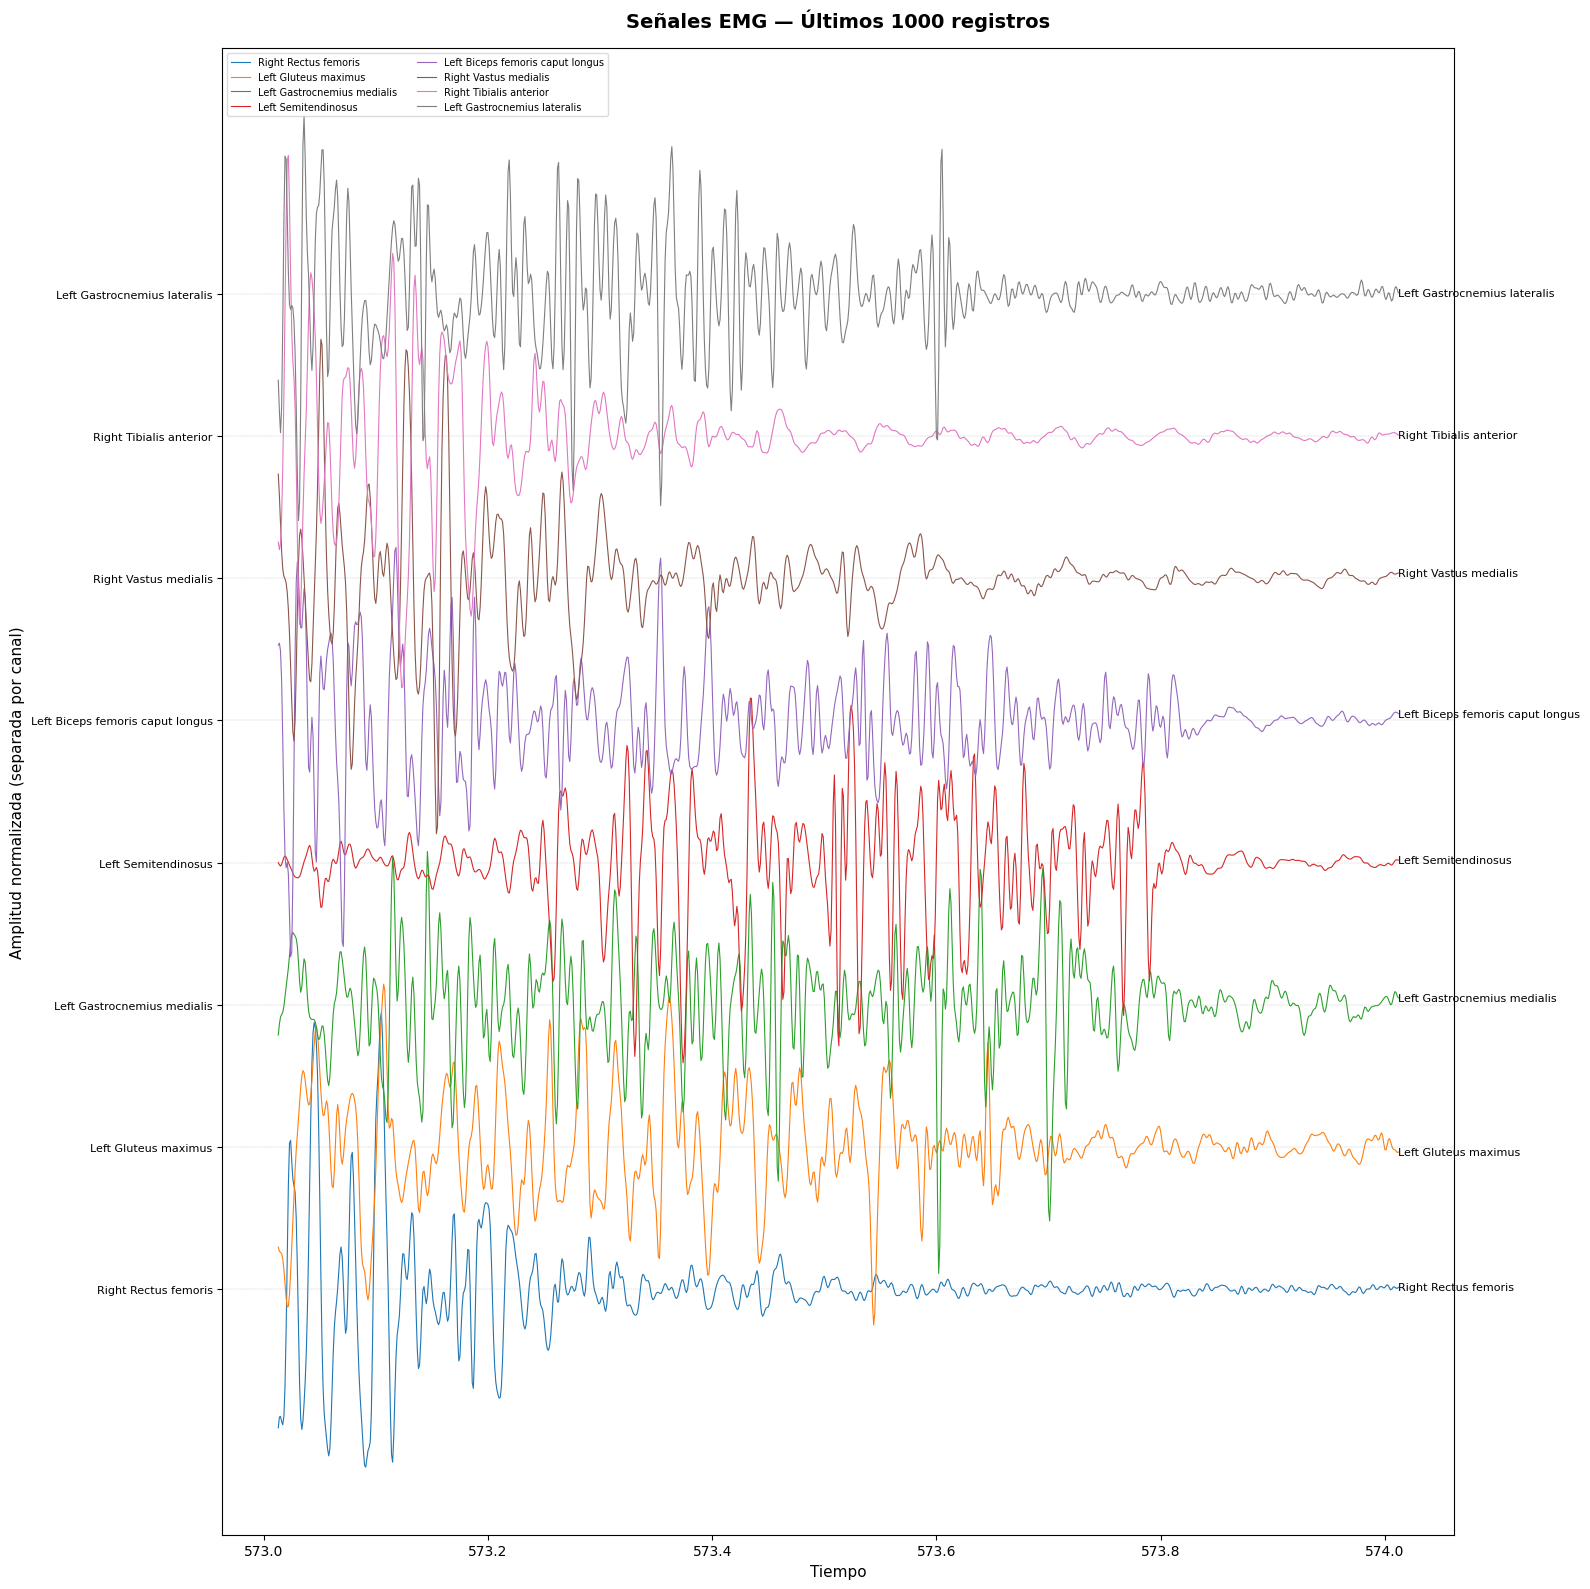

In [19]:
def plot_emg(data, titulo, channels):
    _, ax = plt.subplots(figsize=(16, len(channels) * 2))
    
    # Offset para separar visualmente cada señal
    offset_scale = 3  # Ajusta este valor si las señales siguen solapándose
    
    for i, channel in enumerate(channels):
        señal = data[channel].values
        # Normalizar cada señal para que tengan escala comparable
        señal_norm = (señal - np.mean(señal)) / (np.std(señal) + 1e-8)
        offset = i * offset_scale
        
        ax.plot(data['Time'].values, señal_norm + offset, 
                label=channel, linewidth=0.8)
        
        # Label a la derecha de cada señal
        ax.text(x=data['Time'].values[-1], 
                y=señal_norm[-1] + offset,
                s=channel, 
                fontsize=8, 
                va='center',
                ha='left')
        
        # Línea base punteada por canal para facilitar lectura
        ax.axhline(y=offset, color='gray', linewidth=0.3, linestyle='--', alpha=0.5)
    
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Tiempo', fontsize=11)
    ax.set_ylabel('Amplitud normalizada (separada por canal)', fontsize=11)
    ax.legend(loc='upper left', fontsize=7, ncol=2, 
              bbox_to_anchor=(0, 1), framealpha=0.7)
    
    # Quitar los ticks del eje Y ya que el offset los hace poco informativos
    ax.set_yticks([i * offset_scale for i in range(len(channels))])
    ax.set_yticklabels(channels, fontsize=8)
    
    plt.tight_layout()
    plt.show()


# --- Uso ---
plot_emg(df.head(1000), 'Señales EMG — Primeros 1000 registros', channels)
plot_emg(df.tail(1000), 'Señales EMG — Últimos 1000 registros', channels)

### ¿Qué se puede observar de las señales en el tiempo?

En los primeros 1000 registros del dataset, se observa una actividad muscular intensa en la mayoría de los canales, con picos de alta amplitud que reflejan contracciones activas. El músculo que presenta menor actividad en este intervalo es el Right Vastus medialis, mientras que el Right Tibialis anterior y el left biceps femoris caput longus muestran los picos más pronunciados.

En los últimos 1000 registros se puede apreciar un patrón diferente: aunque inicialmente las señales mantienen una actividad considerable, aproximadamente a partir del segundo 573.5 la amplitud de todas las señales converge progresivamente hacia cero. Esto sugiere que los participantes cesaron la actividad física en ese punto, lo que se refleja en la ausencia de contracciones musculares detectables hacia el final del registro.

Esta diferencia entre el inicio y el final del dataset es relevante, ya que podría indicar que las últimas ventanas de tiempo corresponden a un estado de reposo y no de fatiga activa, lo cual debe tenerse en cuenta al interpretar las etiquetas del target en esa región temporal.

## Paso 4: Procesamiento de Datos

In [20]:


# 1. Separar variables predictoras y target
X = nuevo_df.drop(columns='target')
y = nuevo_df['target']

# 2. División 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# 3. Pipeline de preprocesamiento
pipeline_preprocesamiento = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 4. Calcular mediana en train, para luego imputar en los demas datasets
X_train_proc = pipeline_preprocesamiento.fit_transform(X_train)
X_val_proc = pipeline_preprocesamiento.transform(X_val)
X_test_proc = pipeline_preprocesamiento.transform(X_test)

# 5. Verificación
total_registros = X_train_proc.shape[0] + X_val_proc.shape[0] + X_test_proc.shape[0] 
print("Porcentajes de las clases:")
print("X_train:", X_train_proc.shape[0] / total_registros * 100 , "%") 
print("X_val:", X_val_proc.shape[0] / total_registros * 100 , "%") 
print("X_test:", X_test_proc.shape[0] / total_registros * 100 , "%") 

print("\nDistribución de clases:")
print("Train:")
print(y_train.value_counts(normalize=True))
print("\nVal:")
print(y_val.value_counts(normalize=True))
print("\nTest:")
print(y_test.value_counts(normalize=True))

Porcentajes de las clases:
X_train: 69.98667554963359 %
X_val: 14.990006662225182 %
X_test: 15.023317788141238 %

Distribución de clases:
Train:
target
0    0.70871
1    0.29129
Name: proportion, dtype: float64

Val:
target
0    0.708889
1    0.291111
Name: proportion, dtype: float64

Test:
target
0    0.709534
1    0.290466
Name: proportion, dtype: float64


## Paso 5: Entrenamiento y Comparación de Modelos

In [21]:


param_dist_neighbors = {
    'n_neighbors': randint(10, 30), # Distribucion uniforme discreta    
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev'],
}

kneighbors = RandomizedSearchCV (
    estimator= KNeighborsClassifier(),
    param_distributions=param_dist_neighbors,
    n_iter=50,
    cv=5, # Hace CV 5 veces, rotando cual va a ser la particion VAL en cada cv
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
)

kneighbors.fit(X_train_proc , y_train)
print("Los mejores parametros:" , kneighbors.best_params_)
print("Mejor accuracy:" , kneighbors.best_score_)



Los mejores parametros: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}
Mejor accuracy: 0.8539147237239684


In [22]:
param_dist_dt = {
    'criterion' : ['gini' , 'entropy' , 'log_loss'],
    'splitter' : ['best' , 'random'],
    'max_depth' : [2, 3, 4, 5],
    'class_weight': ['balanced', None],
    'min_samples_split' : randint(3 , 10)
}

decision_tree = RandomizedSearchCV (
    estimator = DecisionTreeClassifier(),
    param_distributions = param_dist_dt,
    n_iter=50,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
)

decision_tree.fit(X_train_proc , y_train)
print("Los mejores parametros:" , decision_tree.best_params_)
print("Mejor accuracy:" , decision_tree.best_score_)

Los mejores parametros: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 3, 'splitter': 'best'}
Mejor accuracy: 0.8274479843849043


In [23]:
param_dist_rf = {
    'n_estimators' : [100,200,300],
    'criterion' : ['gini' , 'entropy' , 'log_loss'],
    'max_depth' : [3, 5, 7],
    'max_features': ['sqrt', 'log2']
}

ramdom_forest = RandomizedSearchCV (
    estimator=RandomForestClassifier(),
    param_distributions=param_dist_rf,
    n_iter=50,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)

ramdom_forest.fit(X_train_proc , y_train)
print("Los mejores parametros:" , ramdom_forest.best_params_)
print("Mejor accuracy:" , ramdom_forest.best_score_)

Los mejores parametros: {'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': 7, 'criterion': 'gini'}
Mejor accuracy: 0.8598308877446875


In [24]:
param_dist_gb = {
    'n_estimators'  : [100, 200, 300],
    'learning_rate' : [0.01, 0.05, 0.07],
    'max_depth'     : [2, 3, 4, 5],
    'subsample'     : [0.7, 0.8, 1.0 , 1.2 , 1.4],
    'loss' : ['log_loss' , 'exponential']
}

gradient_boosting = RandomizedSearchCV (
    estimator= GradientBoostingClassifier(),
    param_distributions=param_dist_gb,
    n_iter=50,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)

gradient_boosting.fit(X_train_proc , y_train)
print("Los mejores parametros:" , gradient_boosting.best_params_)
print("Mejor accuracy:" , gradient_boosting.best_score_)

/home/alejo/Universidad/IA/Taller2/venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
85 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/home/alejo/Universidad/IA/Taller2/venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/alejo/Universidad/IA/Taller2/venv/lib/python3.12/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
  File "/home/alejo/Universidad/IA/Taller2/venv/lib/python3.12/site-packages/sklearn/base.py", line 492, in

Los mejores parametros: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'loss': 'exponential', 'learning_rate': 0.07}
Mejor accuracy: 0.8711798600035283


In [25]:
# F1 no existe nativa, pero se puede construir
class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall    = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * (p * r) / (p + r + 1e-6)  # +1e-6 evita división por cero

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

In [26]:
def crear_modelo(units_1=128, units_2=64, units_3=32,
                 dropout_rate=0.3, learning_rate=0.001, l2_lambda=0.001):
    model = Sequential([
        Input(shape=(X_train_proc.shape[1],)),  # ← capa Input explícita
        Dense(units_1, activation='relu', kernel_regularizer=l2(l2_lambda)),
        Dropout(dropout_rate),

        Dense(units_2, activation='relu', kernel_regularizer=l2(l2_lambda)),
        Dropout(dropout_rate),

        Dense(units_3, activation='relu', kernel_regularizer=l2(l2_lambda)),
        Dropout(dropout_rate * 0.7),  # La última capa siempre un poco menos

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            Precision(name='precision'),
            Recall(name='recall'),
            F1Score(name='f1_score')
        ]
    )
    return model

early_stopping = EarlyStopping(
    monitor='loss',    # Vigila la pérdida en validación
    patience=10,           # Para si no mejora en 10 épocas seguidas
    restore_best_weights=True  # Recupera los pesos del mejor epoch
)

modelo_keras = KerasClassifier(
    model=crear_modelo,
    epochs=50,
    batch_size=32,
    verbose=0,
    callbacks=[early_stopping]
)

param_dist = {
    'model__units_1':       randint(64, 256),     # Neuronas capa 1
    'model__units_2':       randint(32, 128),      # Neuronas capa 2
    'model__units_3':       randint(16, 64),       # Neuronas capa 3
    'model__dropout_rate':  uniform(0.1, 0.4),     # Dropout entre 0.1 y 0.5
    'model__learning_rate': uniform(0.0001, 0.01), # Learning rate
    'model__l2_lambda':     uniform(0.0001, 0.01), # Regularización L2
    'batch_size':           [16, 32, 64]           # Tamaño de batch
}

dnn = RandomizedSearchCV(
    estimator=modelo_keras,
    param_distributions=param_dist,
    n_iter=20,          
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=1            # Con Keras siempre n_jobs=1, no paraleliza bien
)

dnn.fit(X_train_proc , y_train)
print("Los mejores parametros:" , dnn.best_params_)
print("Mejor accuracy:" , dnn.best_score_)

mejor_modelo = dnn.best_estimator_
accuracy_test = mejor_modelo.score(X_test_proc, y_test)
print(f"Test Accuracy: {accuracy_test:.4f}")



E0000 00:00:1774569760.929523    1269 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774569760.930160    6867 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1774569760.948640    1269 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Los mejores parametros: {'batch_size': 64, 'model__dropout_rate': np.float64(0.4400154311159198), 'model__l2_lambda': np.float64(0.004594506741382034), 'model__learning_rate': np.float64(0.0010541011649041131), 'model__units_1': 214, 'model__units_2': 93, 'model__units_3': 39}
Mejor accuracy: 0.8562363879023114
Test Accuracy: 0.8714


In [27]:

# Extraer el mejor estimador de cada Random Search
mejor_knn = kneighbors.best_estimator_
mejor_dt = decision_tree.best_estimator_
mejor_rf  = ramdom_forest.best_estimator_
mejor_gb  = gradient_boosting.best_estimator_
mejor_dnn = dnn.best_estimator_

modelos = {
    'KNN':               mejor_knn,
    'Random Forest':     mejor_rf,
    'Gradient Boosting': mejor_gb,
    'Decision Tree Classifier' : mejor_dt,
    'DNN':               mejor_dnn
}

print(modelos)

def calcular_metricas(nombre, modelo, X, y, conjunto):
    y_pred = modelo.predict(X)
    return {
        'Modelo':    nombre,
        'Conjunto':  conjunto,
        'Accuracy':  accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall':    recall_score(y, y_pred, zero_division=0),
        'F1-Score':  f1_score(y, y_pred, zero_division=0)
    }

{'KNN': KNeighborsClassifier(metric='manhattan', n_neighbors=13, weights='distance'), 'Random Forest': RandomForestClassifier(max_depth=7, n_estimators=200), 'Gradient Boosting': GradientBoostingClassifier(learning_rate=0.07, loss='exponential', max_depth=5,
                           n_estimators=300, subsample=0.8), 'Decision Tree Classifier': DecisionTreeClassifier(max_depth=5, min_samples_split=3), 'DNN': KerasClassifier(
	model=<function crear_modelo at 0x7be79eee22a0>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=64
	validation_batch_size=None
	verbose=0
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x7be79eec27b0>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=50
	class_weight=None
	model__dropout_rate=0.4400154311159198
	model__l2_lambda=0.004594506741382034
	model__learning_rate=0.0010541011649041131
	model__units_1=214
	model__units_2=93
	model__units_3=39
)}


In [50]:
resultados = []

for nombre, modelo in modelos.items():
    resultados.append(calcular_metricas(nombre, modelo, X_train_proc, y_train, 'Train'))
    resultados.append(calcular_metricas(nombre, modelo, X_val_proc,   y_val,   'Val'))
    resultados.append(calcular_metricas(nombre, modelo, X_test_proc,  y_test,  'Test'))

df_resultados = pd.DataFrame(resultados)

# Formatear a 4 decimales
df_display = df_resultados.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_display[col] = df_display[col].map('{:.4f}'.format)

print(df_display.to_string(index=False))

                  Modelo Conjunto Accuracy Precision Recall F1-Score
                     KNN    Train   1.0000    1.0000 1.0000   1.0000
                     KNN      Val   0.8467    0.8039 0.6260   0.7039
                     KNN     Test   0.8736    0.8491 0.6870   0.7595
           Random Forest    Train   0.9139    0.9634 0.7320   0.8319
           Random Forest      Val   0.8467    0.7925 0.6412   0.7089
           Random Forest     Test   0.9024    0.8991 0.7481   0.8167
       Gradient Boosting    Train   1.0000    1.0000 1.0000   1.0000
       Gradient Boosting      Val   0.8822    0.8421 0.7328   0.7837
       Gradient Boosting     Test   0.8847    0.8319 0.7557   0.7920
Decision Tree Classifier    Train   0.8701    0.8709 0.6503   0.7446
Decision Tree Classifier      Val   0.8378    0.7900 0.6031   0.6840
Decision Tree Classifier     Test   0.8581    0.8454 0.6260   0.7193
                     DNN    Train   0.8920    0.8842 0.7239   0.7960
                     DNN      Val 

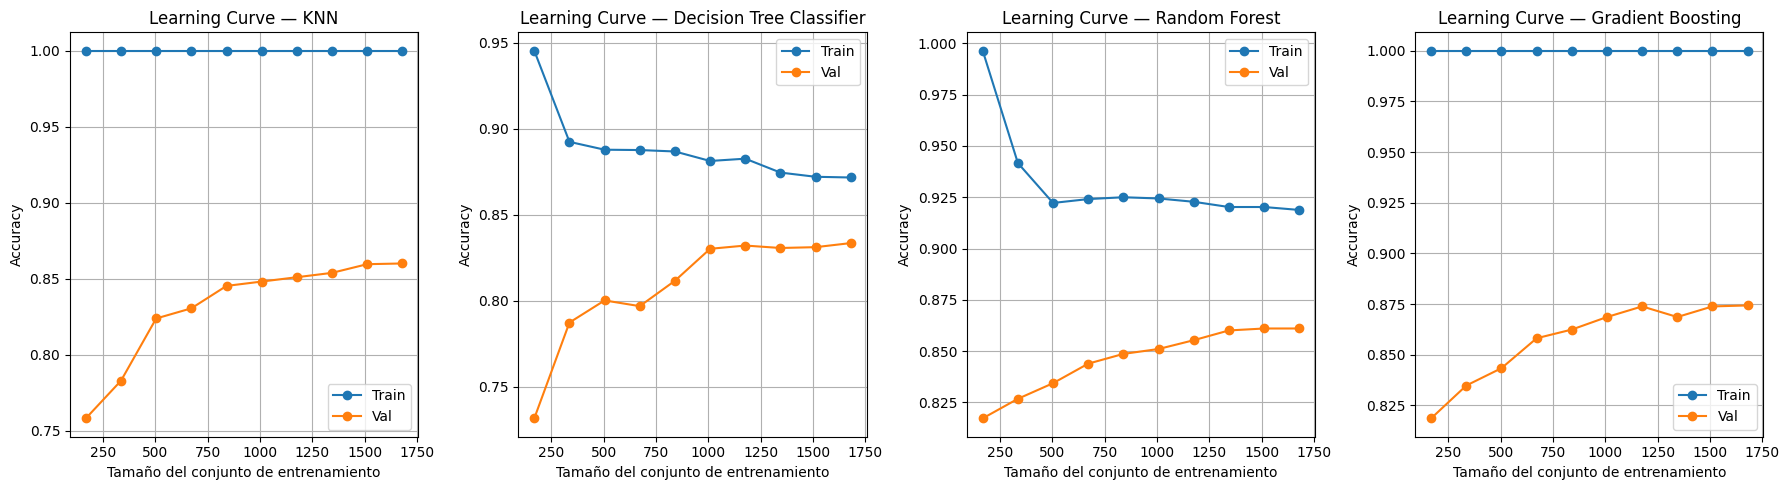

In [29]:

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

modelos_sklearn = {
    'KNN': mejor_knn,
    'Decision Tree Classifier' : mejor_dt,
    'Random Forest': mejor_rf,
    'Gradient Boosting': mejor_gb
}

for ax, (nombre, modelo) in zip(axes, modelos_sklearn.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X_train_proc, y_train,
        cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)

    ax.plot(train_sizes, train_mean, label='Train', marker='o')
    ax.plot(train_sizes, val_mean,   label='Val',   marker='o')
    ax.set_title(f'Learning Curve — {nombre}')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### ¿Qué podemos observar de las curvas de aprendizaje?

Se puede observar que los modelos de KNN y Gradient Boosting sufren de overfitting severo — ambos memorizaron el conjunto de entrenamiento al 100% (accuracy = 1.0), manteniendo una brecha de aproximadamente 15-20% respecto a la curva de validación a lo largo de todo el entrenamiento.

Random Forest presenta un overfitting moderado, con una brecha de aproximadamente 5% entre Train (~0.915) y Validación (~0.865). La curva de validación sigue una tendencia creciente, lo que sugiere que podría seguir mejorando con más datos.

Decision Tree es el modelo con la brecha más pequeña (~4%), aunque esto no lo hace necesariamente el mejor — su curva de validación es la más baja de los cuatro modelos (~0.835), lo que indica que sacrificó capacidad de aprendizaje a cambio de menos sobreajuste. Es el modelo con peor desempeño absoluto en validación.

En general, ninguno de los cuatro modelos logra una convergencia clara entre las curvas de Train y Validación, lo que sugiere que todos se beneficiarían de una regularización más fuerte o de un mayor volumen de datos de entrenamiento.

In [30]:
mejor_params = dnn.best_params_

modelo_final_dnn = crear_modelo(
    units_1       = mejor_params['model__units_1'],
    units_2       = mejor_params['model__units_2'],
    units_3       = mejor_params['model__units_3'],
    dropout_rate  = mejor_params['model__dropout_rate'],
    learning_rate = mejor_params['model__learning_rate'],
    l2_lambda     = mejor_params['model__l2_lambda']
)

early_stopping_final = EarlyStopping(
    monitor='val_loss',         # ← ahora sí podemos usar val_loss
    patience=10,
    restore_best_weights=True
)

history = modelo_final_dnn.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),  # ← ahora sí pasamos validación
    epochs=100,
    batch_size=mejor_params['batch_size'],
    callbacks=[early_stopping_final],
    verbose=1
)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7030 - f1_score: 0.2693 - loss: 1.7822 - precision: 0.4752 - recall: 0.1879 - val_accuracy: 0.7844 - val_f1_score: 0.5571 - val_loss: 1.5794 - val_precision: 0.6932 - val_recall: 0.4656
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7749 - f1_score: 0.5005 - loss: 1.5063 - precision: 0.7075 - recall: 0.3873 - val_accuracy: 0.8022 - val_f1_score: 0.6397 - val_loss: 1.3734 - val_precision: 0.6810 - val_recall: 0.6031
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7991 - f1_score: 0.5966 - loss: 1.3120 - precision: 0.7189 - recall: 0.5098 - val_accuracy: 0.8089 - val_f1_score: 0.6446 - val_loss: 1.2076 - val_precision: 0.7027 - val_recall: 0.5954
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8039 - f1_score: 0.6150 - loss: 1.1698 - precision: 0.7183 - recall: 0.5376 - val_accuracy: 0.8111 - val_f1_score: 0.6640 - val_loss: 1.0780 - val_precision: 0.6885 - val_recall: 0.6

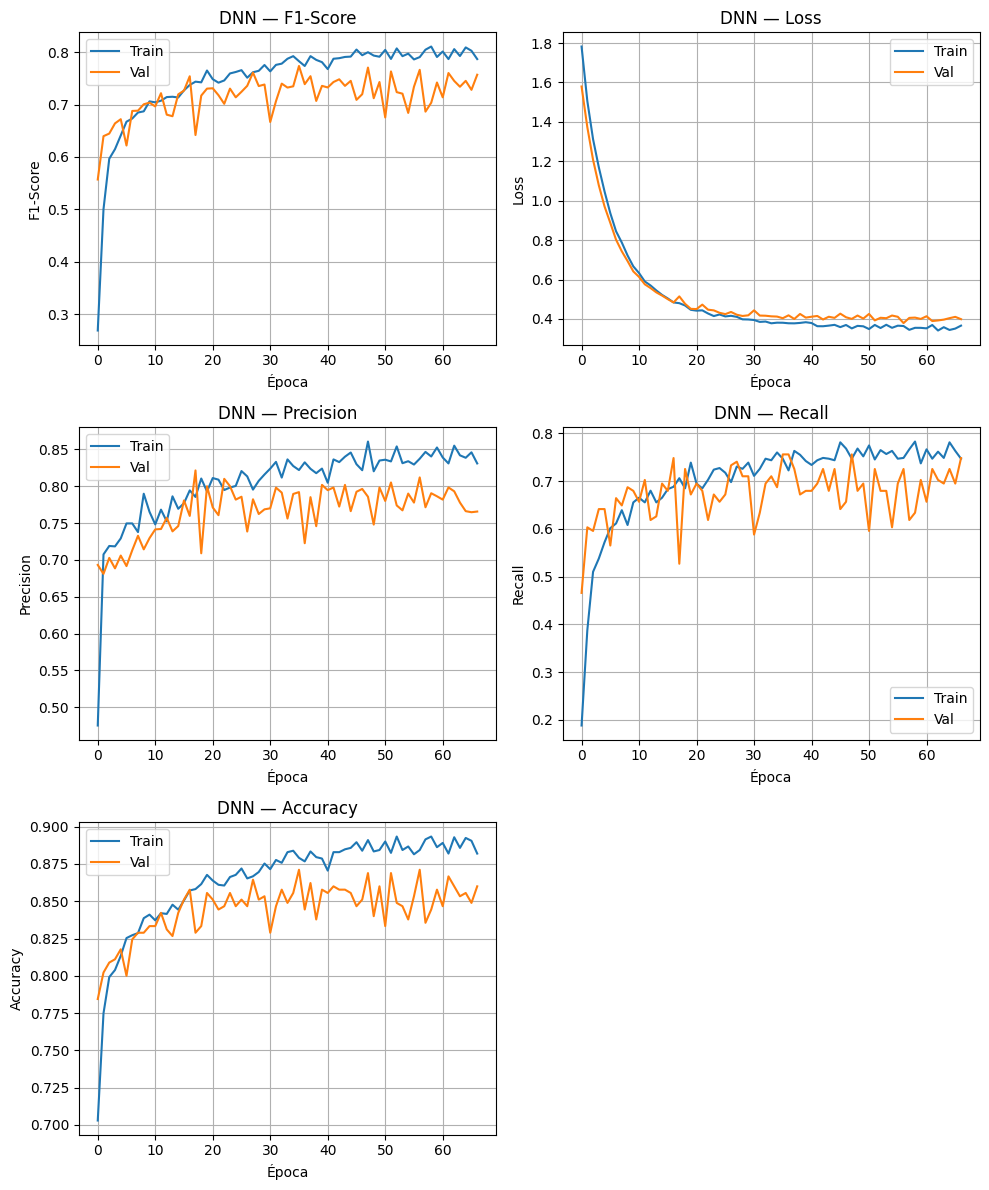

In [31]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

metricas = [
    ('f1_score',  'val_f1_score',  'F1-Score'),
    ('loss',      'val_loss',      'Loss'),
    ('precision', 'val_precision', 'Precision'),
    ('recall',    'val_recall',    'Recall'),
    ('accuracy',  'val_accuracy',  'Accuracy'),
]

for ax, (train_key, val_key, titulo) in zip(axes.flatten(), metricas):
    ax.plot(history.history[train_key], label='Train')
    ax.plot(history.history[val_key],   label='Val')
    ax.set_title(f'DNN — {titulo}')
    ax.set_xlabel('Época')
    ax.set_ylabel(titulo)
    ax.legend()
    ax.grid(True)

axes.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.show()

### ¿Qué observamos en la DNN?

La red neuronal profunda fue el modelo con mejor generalización de todos los evaluados. Esto se evidencia principalmente en la curva de Loss, donde ambas curvas (Train y Val) descienden de manera conjunta desde ~1.75 hasta ~0.40, sin que la pérdida de validación vuelva a subir. Este comportamiento indica que el modelo aprendió patrones reales y no memorizó los datos de entrenamiento.

En cuanto al F1-Score, se observa una brecha pequeña y estable entre Train (~0.78) y Val (~0.72), con una tendencia creciente sostenida a lo largo de las épocas. La curva de Precision es una de las más estable de las cinco métricas, con Train y Val prácticamente paralelas (~0.82 vs ~0.79), lo que sugiere que cuando el modelo predice un caso de fatiga, lo hace con consistencia.

La métrica más ruidosa es el Recall, cuya curva de validación oscila considerablemente entre épocas sin estabilizarse del todo. Esto indica que el modelo aún presenta cierta inconsistencia detectando todos los casos reales de fatiga, lo cual es el aspecto con mayor margen de mejora para iteraciones futuras.

### Veredicto

En general, la DNN es el modelo que mejor equilibra aprendizaje y generalización frente a los demás modelos evaluados, obteniendo un F1-Score de 0.789 en Test con una brecha Train-Val de apenas ~0.087 — 
la más pequeña de todos los modelos. En términos de producción, este modelo sería el más apto para la clasificación de señales musculares entre fatigado y no fatigado.

## Paso 6: Evaluación Final del Mejor Modelo

In [32]:
mejor_params = dnn.best_params_

modelo_final_dnn = crear_modelo(
    units_1       = mejor_params['model__units_1'],
    units_2       = mejor_params['model__units_2'],
    units_3       = mejor_params['model__units_3'],
    dropout_rate  = mejor_params['model__dropout_rate'],
    learning_rate = mejor_params['model__learning_rate'],
    l2_lambda     = mejor_params['model__l2_lambda']
)

early_stopping_final = EarlyStopping(
    monitor='val_loss',         # ← ahora sí podemos usar val_loss
    patience=10,
    restore_best_weights=True
)

# Train + val
X_train_final = np.concatenate([X_train_proc, X_val_proc], axis=0)
y_train_final = np.concatenate([y_train, y_val], axis=0)


history = modelo_final_dnn.fit(
    X_train_final, y_train_final,
    validation_split=0.1,        # Pequeña partición interna solo para early stopping
    epochs=100,
    batch_size=mejor_params['batch_size'],
    callbacks=[early_stopping_final],
    verbose=1
)

y_pred_final = (modelo_final_dnn.predict(X_test_proc) >= 0.5).astype(int)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6893 - f1_score: 0.2863 - loss: 1.7653 - precision: 0.4231 - recall: 0.2163 - val_accuracy: 0.7578 - val_f1_score: 0.4259 - val_loss: 1.5617 - val_precision: 0.8846 - val_recall: 0.2805
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7669 - f1_score: 0.4623 - loss: 1.4545 - precision: 0.6886 - recall: 0.3480 - val_accuracy: 0.7969 - val_f1_score: 0.6000 - val_loss: 1.3354 - val_precision: 0.8125 - val_recall: 0.4756
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7882 - f1_score: 0.5653 - loss: 1.2531 - precision: 0.6915 - recall: 0.4781 - val_accuracy: 0.8164 - val_f1_score: 0.6519 - val_loss: 1.1603 - val_precision: 0.8302 - val_recall: 0.5366
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8118 - f1_score: 0.6482 - loss: 1.0929 - precision: 0.7019 - recall: 0.6021 - val_accuracy: 0.8203 - val_f1_score: 0.6618 - val_loss: 1.0156 - val_precision: 0.8333 - val_recall: 0.5

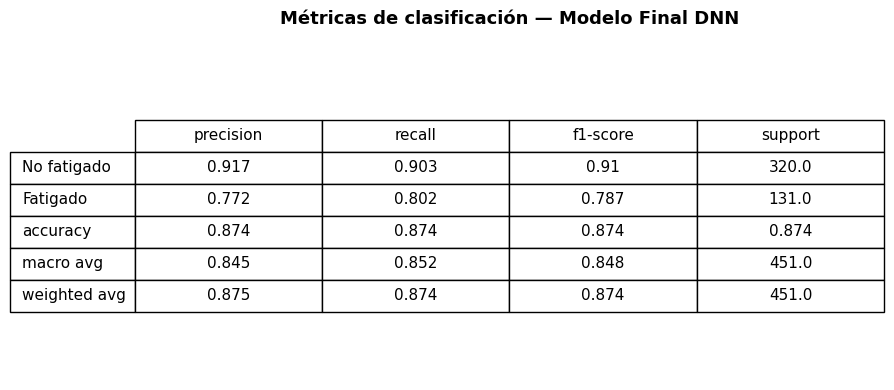

In [34]:


report = classification_report(y_test, y_pred_final, 
                                target_names=['No fatigado', 'Fatigado'],
                                output_dict=True)

df_report = pd.DataFrame(report).transpose()

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
tabla = ax.table(
    cellText  = df_report.round(3).values,
    rowLabels = df_report.index,
    colLabels = df_report.columns,
    cellLoc   = 'center',
    loc       = 'center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.4, 1.8)

plt.title('Métricas de clasificación — Modelo Final DNN', 
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

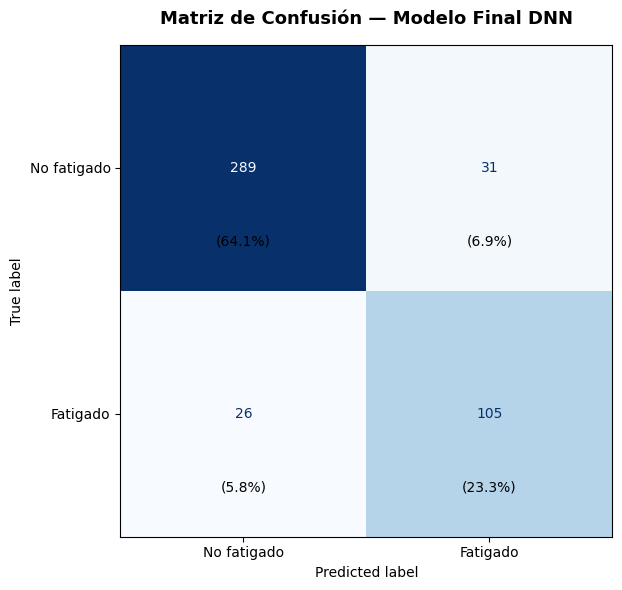

In [35]:
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No fatigado', 'Fatigado'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

# Anotar porcentajes dentro de cada celda
total = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        pct = cm[i, j] / total * 100
        ax.text(j, i + 0.3, f'({pct:.1f}%)', 
                ha='center', va='center', 
                fontsize=10, color='black')

ax.set_title('Matriz de Confusión — Modelo Final DNN', 
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### ¿Cómo fue el rendimiento del modelo?

El rendimiento del modelo fue bastante aceptable, con únicamente un 5.8% de Falsos Negativos. Teniendo en cuenta el desbalance de clases presente en el dataset (70/30), este resultado es satisfactorio.

Como posibles mejoras se podrían considerar las siguientes:

- Ajustar el umbral de clasificación bajándolo por debajo de 0.5 para priorizar el Recall de la clase fatigado, reduciendo los Falsos Negativos a costa de un leve aumento en los Falsos Positivos.

- Aplicar PCA para reducir la redundancia entre las 56 features. Como se pudo observar en la matriz de correlaciones del EDA, varios músculos presentan features altamente correlacionadas, lo que introduce información duplicada que PCA podría consolidar.

- Incorporar Batch Normalization entre capas densas, lo cual estabiliza las activaciones manteniéndolas en una distribución controlada a lo largo de la red, evitando que los gradientes se disparen o desaparezcan durante el entrenamiento.

- Explorar la adición de una capa densa adicional, lo cual podría ser beneficioso dado el número considerable de features disponibles y la complejidad de los patrones de fatiga muscular.

## Paso 7: Prueba con Muestra Artificial

In [38]:

# Para generar valores "aproximados a los reales"
print("Estadísticas de las features seleccionadas:")
display(X_train[todos_los_musculos].describe().round(4))

Estadísticas de las features seleccionadas:


,Right Rectus femoris_rms,Right Rectus femoris_var,Right Rectus femoris_zcr,Right Rectus femoris_mav,Right Rectus femoris_pot,Right Rectus femoris_f_media,Right Rectus femoris_f_mediana,Left Gluteus maximus_rms,Left Gluteus maximus_var,Left Gluteus maximus_zcr,...,Right Tibialis anterior_pot,Right Tibialis anterior_f_media,Right Tibialis anterior_f_mediana,Left Gastrocnemius lateralis_rms,Left Gastrocnemius lateralis_var,Left Gastrocnemius lateralis_zcr,Left Gastrocnemius lateralis_mav,Left Gastrocnemius lateralis_pot,Left Gastrocnemius lateralis_f_media,Left Gastrocnemius lateralis_f_mediana
count,2101.0000,2101.0000,2101.0000,2101.0000,2101.0000,2101.0000,2101.0000,2101.0000,2101.0000,2101.0000,...,2101.0000,2101.0000,2101.0000,2101.0000,2101.0000,2101.0000,2101.0000,2101.0000,2101.0000,2101.0000
mean,0.0352,0.0018,108.7544,0.0223,0.0005,53.8577,47.2952,0.0115,0.0004,120.5007,...,0.0008,71.1888,66.6591,0.0513,0.0035,136.4688,0.0339,0.0009,70.9371,65.8057
std,0.0240,0.0035,12.9570,0.0150,0.0010,6.2648,8.3265,0.0173,0.0024,17.9600,...,0.0019,15.1686,17.5579,0.0300,0.0044,21.5068,0.0215,0.0012,12.4070,16.9905
min,0.0030,0.0000,63.0000,0.0022,0.0000,20.4871,15.6250,0.0028,0.0000,46.0000,...,0.0000,28.9817,19.5312,0.0029,0.0000,66.0000,0.0020,0.0000,26.3451,11.7188
25%,0.0212,0.0005,100.0000,0.0133,0.0001,50.5043,42.9688,0.0053,0.0000,110.0000,...,0.0001,65.3758,58.5938,0.0296,0.0009,124.0000,0.0193,0.0002,66.9779,62.5000
50%,0.0292,0.0009,108.0000,0.0183,0.0002,54.4114,46.8750,0.0070,0.0000,122.0000,...,0.0002,72.0686,66.4062,0.0431,0.0019,134.0000,0.0276,0.0005,72.1369,66.4062
75%,0.0415,0.0017,117.0000,0.0265,0.0004,57.9222,50.7812,0.0109,0.0001,133.0000,...,0.0005,80.5690,78.1250,0.0661,0.0044,147.0000,0.0437,0.0011,77.7690,74.2188
max,0.1907,0.0364,151.0000,0.1284,0.0115,71.6942,74.2188,0.1964,0.0386,174.0000,...,0.0203,107.8194,121.0938,0.1902,0.0362,210.0000,0.1476,0.0097,109.9367,113.2812


In [37]:
np.random.seed(42)
# Toma media y std de cada feature del conjunto de entrenamiento para que los valores generados sean estadísticamente plausibles
muestra_dict = {}
for feature in todos_los_musculos:
    media = X_train[feature].mean()
    std   = X_train[feature].std()
    valor = np.random.normal(loc=media, scale=std)
    muestra_dict[feature] = round(valor, 6)

muestra_df = pd.DataFrame([muestra_dict])

print("🧪 Muestra aleatoria generada:")
display(muestra_df)

🧪 Muestra aleatoria generada:


,Right Rectus femoris_rms,Right Rectus femoris_var,Right Rectus femoris_zcr,Right Rectus femoris_mav,Right Rectus femoris_pot,Right Rectus femoris_f_media,Right Rectus femoris_f_mediana,Left Gluteus maximus_rms,Left Gluteus maximus_var,Left Gluteus maximus_zcr,...,Right Tibialis anterior_pot,Right Tibialis anterior_f_media,Right Tibialis anterior_f_mediana,Left Gastrocnemius lateralis_rms,Left Gastrocnemius lateralis_var,Left Gastrocnemius lateralis_zcr,Left Gastrocnemius lateralis_mav,Left Gastrocnemius lateralis_pot,Left Gastrocnemius lateralis_f_media,Left Gastrocnemius lateralis_f_mediana
0,0.04707,0.001322,117.146493,0.045216,0.000243,52.390855,60.444519,0.02483,-0.00069,130.245106,...,-0.000069,87.223813,72.692321,-0.001711,0.004964,128.186936,0.019356,0.001606,83.728702,81.628629


In [39]:
muestra_proc = pipeline_preprocesamiento.transform(muestra_df)

# Probabilidad de fatiga
prob_fatiga = modelo_final_dnn.predict(muestra_proc)[0][0]

# Clasificación con umbral 0.5
prediccion = 1 if prob_fatiga >= 0.5 else 0
etiqueta   = "🔴 FATIGADO" if prediccion == 1 else "🟢 NO FATIGADO"

print(f"\n{'='*50}")
print(f"  Probabilidad de fatiga:  {prob_fatiga:.4f} ({prob_fatiga*100:.1f}%)")
print(f"  Clasificación:           {etiqueta}")
print(f"{'='*50}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

  Probabilidad de fatiga:  0.7898 (79.0%)
  Clasificación:           🔴 FATIGADO


In [40]:
# Para analizar si la muestra tiene sentido contextualmente
promedios_0 = X_train[todos_los_musculos][y_train == 0].mean()
promedios_1 = X_train[todos_los_musculos][y_train == 1].mean()

df_comparacion = pd.DataFrame({
    'Muestra generada'      : muestra_df.iloc[0],
    'Promedio No fatigado'  : promedios_0.round(6),
    'Promedio Fatigado'     : promedios_1.round(6),
})

print("\n📊 Comparación de la muestra con los promedios reales por clase:")
display(df_comparacion)

# Distancia de la muestra a cada clase (distancia euclidiana simple)
dist_0 = np.linalg.norm(muestra_df.values - promedios_0.values)
dist_1 = np.linalg.norm(muestra_df.values - promedios_1.values)

print(f"\n  Distancia al centroide No fatigado: {dist_0:.4f}")
print(f"  Distancia al centroide Fatigado:    {dist_1:.4f}")
print(f"\n  → La muestra está más cerca de: {'🔴 Fatigado' if dist_1 < dist_0 else '🟢 No fatigado'}")
print(f"  → El modelo predijo:             {etiqueta}")

if (dist_1 < dist_0) == (prediccion == 1):
    print("\n  ✅ El resultado tiene sentido — la predicción es consistente")
    print("     con la cercanía de la muestra al centroide de su clase.")
else:
    print("\n  ⚠️  El resultado merece análisis — la predicción no coincide")
    print("     con la clase más cercana en términos de distancia euclidiana.")


📊 Comparación de la muestra con los promedios reales por clase:


,Muestra generada,Promedio No fatigado,Promedio Fatigado
Right Rectus femoris_rms,0.047070,0.034540,0.036689
Right Rectus femoris_var,0.001322,0.001769,0.001911
Right Rectus femoris_zcr,117.146493,108.284755,109.897059
Right Rectus femoris_mav,0.045216,0.022010,0.022989
Right Rectus femoris_pot,0.000243,0.000462,0.000478
Right Rectus femoris_f_media,52.390855,53.929619,53.682626
Right Rectus femoris_f_mediana,60.444519,47.234406,47.443066
Left Gluteus maximus_rms,0.024830,0.011239,0.012292
Left Gluteus maximus_var,-0.000690,0.000484,0.000308
Left Gluteus maximus_zcr,130.245106,121.913365,117.063725



  Distancia al centroide No fatigado: 88.7260
  Distancia al centroide Fatigado:    86.4832

  → La muestra está más cerca de: 🔴 Fatigado
  → El modelo predijo:             🔴 FATIGADO

  ✅ El resultado tiene sentido — la predicción es consistente
     con la cercanía de la muestra al centroide de su clase.
